In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.stats.stattools import durbin_watson

In [11]:
ind_prod     = pd.read_csv('data/INDPRO.csv',   index_col=0, parse_dates=True)
hour_earnings = pd.read_csv('data/AHETPI.csv',   index_col=0, parse_dates=True)
cpi           = pd.read_csv('data/CPIAUCSL.csv', index_col=0, parse_dates=True)

# Align on a common monthly index and filter to 1964–present
df = pd.concat([ind_prod, hour_earnings, cpi], axis=1)
df.columns = ['INDPRO', 'AHETPI', 'CPIAUCSL']
df = df.loc['1964-01-01':]

# Compute log-differences (growth rates / inflation)
df_growth = np.log(df).diff().dropna()
df_growth.columns = ['indpro_g', 'wage_g', 'inflation']

print(f"Sample: {df_growth.index[0].date()} to {df_growth.index[-1].date()}  ({len(df_growth)} obs)")
df_growth.describe()

Sample: 1964-02-01 to 2026-01-01  (742 obs)


,indpro_g,wage_g,inflation
count,742.000000,742.000000,742.000000
mean,0.001761,0.003424,0.003173
std,0.009554,0.002851,0.003153
min,-0.141422,-0.008039,-0.017864
25%,-0.002002,0.001875,0.001556
50%,0.002319,0.003190,0.002768
75%,0.006265,0.004579,0.004659
max,0.063472,0.041419,0.017938


---
# 2.a

In [12]:
# Part a: VAR(1) on growth rates [indpro_g, wage_g, inflation]
model = VAR(df_growth)
var1  = model.fit(1)
print(var1.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 06, Mar, 2026
Time:                     13:28:49
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -33.2173
Nobs:                     741.000    HQIC:                  -33.2632
Log likelihood:           9192.37    FPE:                3.47929e-15
AIC:                     -33.2919    Det(Omega_mle):     3.42355e-15
--------------------------------------------------------------------
Results for equation indpro_g
                  coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------------
const                0.000386         0.000599            0.645           0.519
L1.indpro_g          0.277327         0.037218            7.451           0.000
L1.wage_g            0.227330         0.128360            1.7

/Users/olegglotov/Documents/CHICAGO code/Winter/FINM - Time Series/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


---
# 2.b

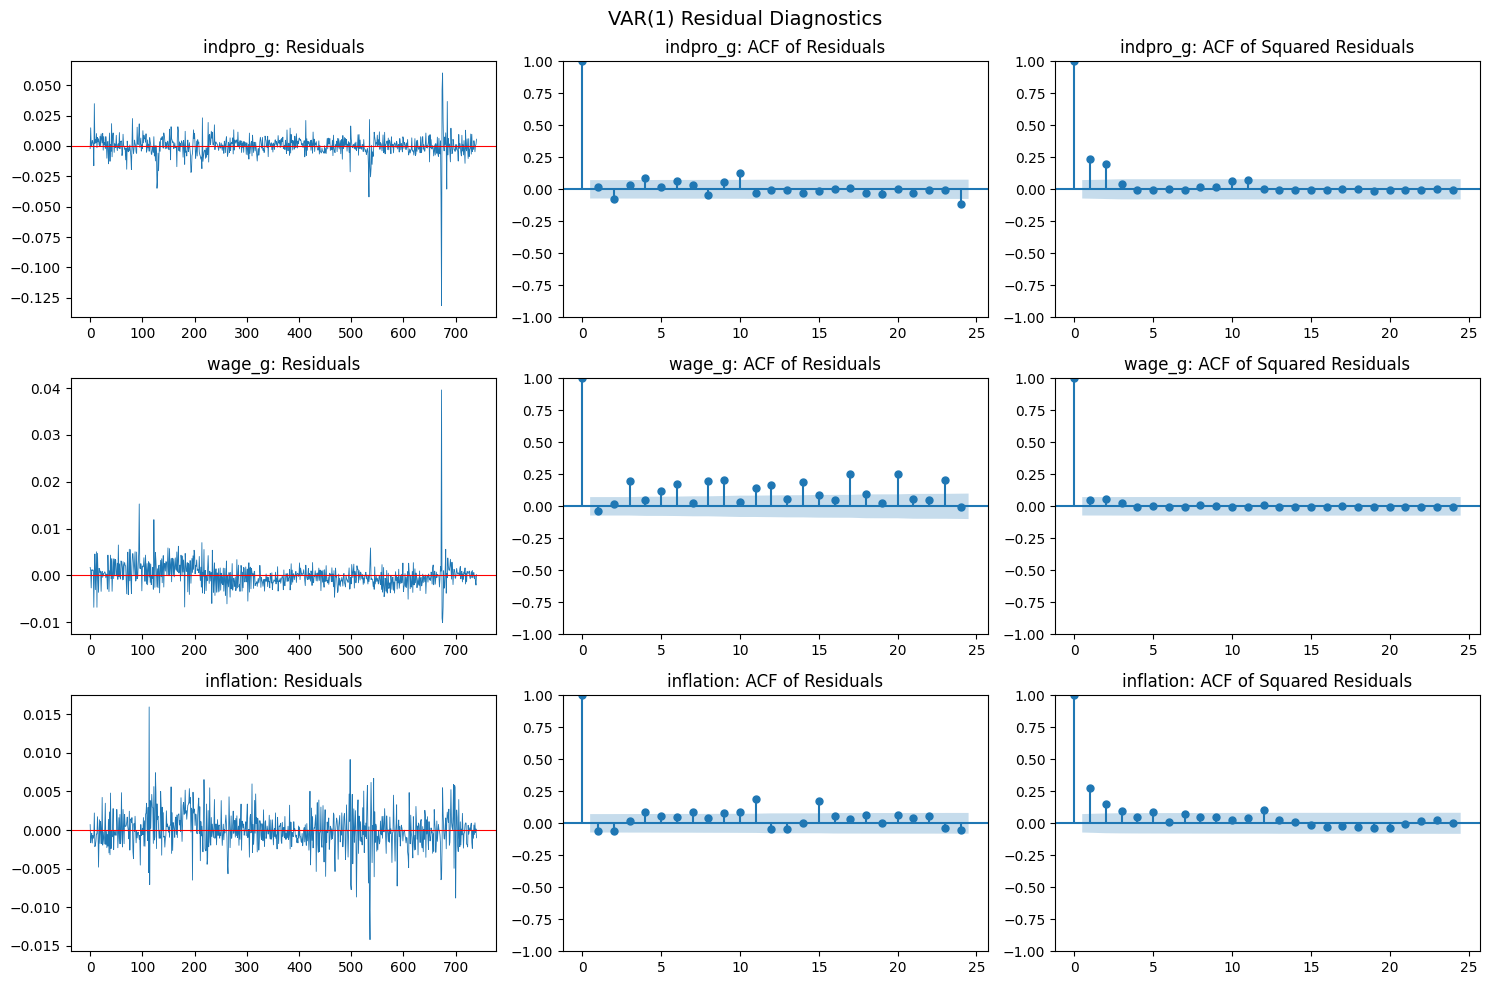

Durbin-Watson statistics (VAR(1)):
  indpro_g: 1.9693
  wage_g: 2.0788
  inflation: 2.1190

Portmanteau test for serial correlation (VAR(1)):
Portmanteau-test for residual autocorrelation. H_0: residual autocorrelation up to lag 12 is zero. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value df
----------------------------------------
         433.8          123.2   0.000 99
----------------------------------------


In [13]:
# Part b: Residual diagnostics for VAR(1)
var_names = ['indpro_g', 'wage_g', 'inflation']
residuals = var1.resid

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
fig.suptitle('VAR(1) Residual Diagnostics', fontsize=14)
for i, name in enumerate(var_names):
    resid = residuals[name]
    axes[i, 0].plot(resid.values, linewidth=0.6)
    axes[i, 0].axhline(0, color='red', linewidth=0.8)
    axes[i, 0].set_title(f'{name}: Residuals')
    sm.graphics.tsa.plot_acf(resid,    lags=24, ax=axes[i, 1], alpha=0.05)
    axes[i, 1].set_title(f'{name}: ACF of Residuals')
    sm.graphics.tsa.plot_acf(resid**2, lags=24, ax=axes[i, 2], alpha=0.05)
    axes[i, 2].set_title(f'{name}: ACF of Squared Residuals')
plt.tight_layout()
plt.show()

print("Durbin-Watson statistics (VAR(1)):")
for name in var_names:
    print(f"  {name}: {durbin_watson(residuals[name]):.4f}")

print("\nPortmanteau test for serial correlation (VAR(1)):")
print(var1.test_whiteness(nlags=12).summary())

In [15]:
# Lag order selection and improved model
print("=== Lag Order Selection (up to 12 lags) ===")
lag_sel = model.select_order(maxlags=12)
print(lag_sel.summary())

optimal_p = lag_sel.aic
print(f"\nAIC → p={lag_sel.aic},  BIC → p={lag_sel.bic},  HQIC → p={lag_sel.hqic}")

var_opt = model.fit(optimal_p)
print(f"\n=== VAR({optimal_p}) Summary ===")
print(var_opt.summary())

test_nlags = max(20, optimal_p + 5)
print(f"\nPortmanteau test (VAR({optimal_p}), nlags={test_nlags}):")
print(var_opt.test_whiteness(nlags=test_nlags).summary())

residuals_opt = var_opt.resid
print(f"\nDurbin-Watson (VAR({optimal_p})):")
for name in var_names:
    print(f"  {name}: {durbin_watson(residuals_opt[name]):.4f}")

=== Lag Order Selection (up to 12 lags) ===
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -32.71      -32.69   6.215e-15      -32.70
1       -33.31      -33.23   3.422e-15      -33.28
2       -33.37      -33.24   3.225e-15      -33.32
3       -33.49     -33.30*   2.856e-15     -33.42*
4       -33.51      -33.27   2.796e-15      -33.42
5       -33.53      -33.22   2.751e-15      -33.41
6       -33.55      -33.19   2.698e-15      -33.41
7       -33.54      -33.13   2.703e-15      -33.38
8       -33.55      -33.08   2.685e-15      -33.37
9       -33.59      -33.06   2.592e-15      -33.38
10      -33.60      -33.02   2.557e-15      -33.37
11      -33.59      -32.95   2.572e-15      -33.35
12     -33.61*      -32.91  2.536e-15*      -33.34
--------------------------------------------------

AIC → p=12,  BIC → p=3,  HQIC → p=3

=== VAR(12) Summary ===
  Summary of Regression Res

---
# 2.c

VAR(1) slope matrix B:
           indpro_g  wage_g  inflation
indpro_g     0.2773  0.2273     0.0327
wage_g      -0.0053  0.0323     0.2373
inflation    0.0118  0.1663     0.5781

Eigenvalue                          Modulus
--------------------------------------------
  0.645809                        0.645809
  0.267799                        0.267799
  -0.025925                       0.025925

Largest modulus (dominant eigenvalue): 0.645809
All inside unit circle (stationary):   True


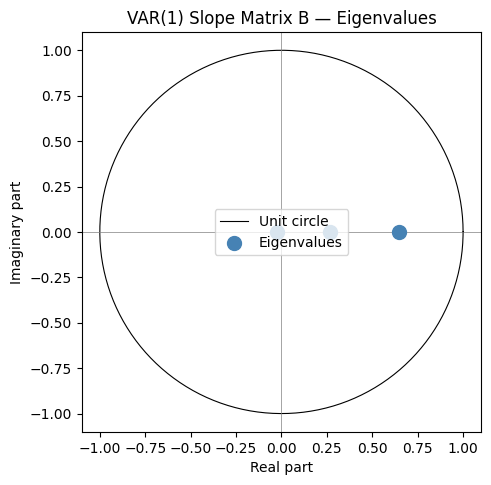


Interpretation:
- The VAR(1) model is Y_t = B*Y_{t-1} + u_t. After a shock at t=0, the system evolves
  as B^h * shock at horizon h. The eigenvalues of B determine how B^h behaves as h grows.

- Each eigenvalue λ corresponds to a "mode" of the system. Its modulus |λ| is the
  per-period decay rate for that mode:
    h periods after a shock, that mode's contribution is scaled by |λ|^h.

- |λ| close to 1  →  slow decay, high persistence (shocks linger for many months).
- |λ| close to 0  →  fast decay, shocks vanish within a few periods.
- |λ| = 1  →  unit root, shocks are permanent and the series is non-stationary.
- |λ| > 1  →  explosive, the system is unstable.

- Complex eigenvalues (a ± bi) imply oscillatory adjustment: the impulse response
  spirals inward rather than decaying monotonically. The oscillation period is
  2π / arctan(b/a) months.

- The largest modulus is the dominant eigenvalue; it controls the long-run rate of
  decay and gives a single summary measure of how persis

In [18]:
# Part c: Eigenvalues of the VAR(1) slope matrix B
# For VAR(1):  Y_t = B * Y_{t-1} + u_t
# B is 3x3, so it has exactly 3 eigenvalues — one per variable in the system.
# These eigenvalues directly characterise how quickly shocks die off.

B = var1.coefs[0]   # 3x3 slope matrix from the VAR(1) in part a
print("VAR(1) slope matrix B:")
print(pd.DataFrame(B, index=var_names, columns=var_names).round(4))

eigenvalues = np.linalg.eigvals(B)

print(f"\n{'Eigenvalue':<32} {'Modulus':>10}")
print("-" * 44)
for ev in sorted(eigenvalues, key=lambda x: -abs(x)):
    print(f"  {str(np.round(ev, 6)):<30}  {abs(ev):.6f}")

print(f"\nLargest modulus (dominant eigenvalue): {max(abs(eigenvalues)):.6f}")
print(f"All inside unit circle (stationary):   {all(abs(eigenvalues) < 1)}")

# Plot eigenvalues relative to the unit circle
fig, ax = plt.subplots(figsize=(5, 5))
theta = np.linspace(0, 2 * np.pi, 300)
ax.plot(np.cos(theta), np.sin(theta), 'k-', linewidth=0.8, label='Unit circle')
ax.scatter(eigenvalues.real, eigenvalues.imag, color='steelblue', s=100, zorder=5, label='Eigenvalues')
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_aspect('equal')
ax.set_title('VAR(1) Slope Matrix B — Eigenvalues')
ax.set_xlabel('Real part')
ax.set_ylabel('Imaginary part')
ax.legend()
plt.tight_layout()
plt.show()

print("""
Interpretation:
- The VAR(1) model is Y_t = B*Y_{t-1} + u_t. After a shock at t=0, the system evolves
  as B^h * shock at horizon h. The eigenvalues of B determine how B^h behaves as h grows.

- Each eigenvalue λ corresponds to a "mode" of the system. Its modulus |λ| is the
  per-period decay rate for that mode:
    h periods after a shock, that mode's contribution is scaled by |λ|^h.

- |λ| close to 1  →  slow decay, high persistence (shocks linger for many months).
- |λ| close to 0  →  fast decay, shocks vanish within a few periods.
- |λ| = 1  →  unit root, shocks are permanent and the series is non-stationary.
- |λ| > 1  →  explosive, the system is unstable.

- Complex eigenvalues (a ± bi) imply oscillatory adjustment: the impulse response
  spirals inward rather than decaying monotonically. The oscillation period is
  2π / arctan(b/a) months.

- The largest modulus is the dominant eigenvalue; it controls the long-run rate of
  decay and gives a single summary measure of how persistent the system is overall.
""")